In [7]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

sns.set_theme()
%config InlineBackend.figure_format = 'svg'

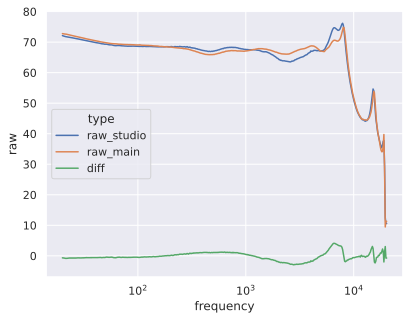

In [8]:
df_studio_l = pd.read_csv(
    "../measurements/dhrme/studio_anc[1].csv", names=["frequency", "raw"]
)
df_studio_r = pd.read_csv(
    "../measurements/dhrme/studio_anc[2].csv", names=["frequency", "raw"]
)
df_main_l = pd.read_csv(
    "../measurements/dhrme/main_anc[1].csv", names=["frequency", "raw"]
)
df_main_r = pd.read_csv(
    "../measurements/dhrme/main_anc[2].csv", names=["frequency", "raw"]
)

# average l/r
df_studio = (df_studio_l + df_studio_r) / 2
df_main = (df_main_l + df_main_r) / 2

# merge
df = pd.merge(df_studio, df_main, on="frequency", suffixes=("_studio", "_main"))
df["diff"] = df["raw_studio"] - df["raw_main"]

# melt
df_melted = df.melt(
    id_vars=["frequency"],
    value_vars=["raw_studio", "raw_main", "diff"],
    var_name="type",
    value_name="raw",
)

sns.lineplot(data=df_melted, x="frequency", y="raw", hue="type")
plt.xscale("log")
plt.show()

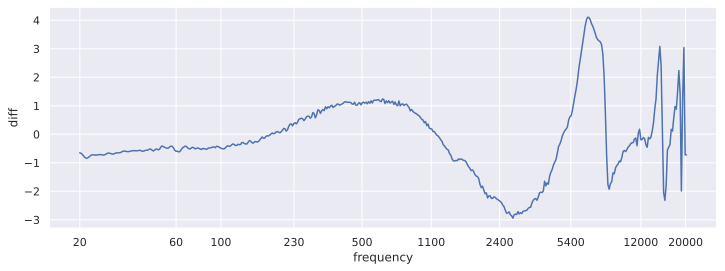

In [9]:
# wider plot
plt.figure(figsize=(12, 4))
sns.lineplot(data=df, x="frequency", y="diff")
bands = [20, 60, 100, 230, 500, 1100, 2400, 5400, 12000, 20000]
plt.xscale("log")
plt.xticks(bands, [str(b) for b in bands])
plt.show()

In [10]:
df[["frequency", "diff"]].rename(columns={"diff": "raw"}).round(2).to_csv(
    "../signatures/dhrme.csv", index=False
)